In [ ]:
## En caso de que decidas trabajar localmente, se recomienda crear un ambiente
## e instalar las librerías. Además deberás cargar localmente las imágenes.
!pip install pandas
!pip install matplotlib
!pip install opencv-python
!pip install mediapipe
!pip install scikit-activeml

In [43]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from skactiveml.pool import RandomSampling, QueryByCommittee, UncertaintySampling
from skactiveml.utils import MISSING_LABEL, labeled_indices
from skactiveml.classifier import SklearnClassifier
from sklearn.base import clone
import kagglehub

# Generar Dataset

Este codigo genera el dataset con los landmarks automáticamente. No modificar.

In [19]:
import urllib.request
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from sklearn.model_selection import train_test_split

# 1. Descarga del dataset y del modelo
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

# 2. Configuración de MediaPipe
base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
hand_landmarker = vision.HandLandmarker.create_from_options(options)

# 3. Funciones de extracción
def extract_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = hand_landmarker.detect(mp_image)

    if results.hand_landmarks:
        all_hand_landmarks = results.hand_landmarks
        coords = []
        for hand_landmarks_list in all_hand_landmarks:
            for lm in hand_landmarks_list:
                coords.extend([lm.x, lm.y, lm.z])
        return coords
    return None

def process_dataset(base_dir, letters=None, max_per_class=1000):
    if letters is None:
        letters = []

    data = []
    total_por_categoria = {}
    detectadas_por_categoria = {}

    for label in letters:
        label_dir = os.path.join(base_dir, label)
        if not os.path.isdir(label_dir):
            continue

        total_por_categoria[label] = 0
        detectadas_por_categoria[label] = 0

        all_images = os.listdir(label_dir)
        rng = np.random.default_rng(42)
        selected_images = rng.choice(
            all_images,
            size=min(max_per_class, len(all_images)),
            replace=False
        )

        for img_file in tqdm(selected_images, desc=f"Procesando {label}"):
            total_por_categoria[label] += 1
            img_path = os.path.join(label_dir, img_file)

            features = extract_landmarks(img_path)

            if features:
                detectadas_por_categoria[label] += 1
                data.append(features + [label, img_file])

    return data, total_por_categoria, detectadas_por_categoria

# 4. Ejecución de la extracción
train_dir = os.path.join(path, "asl_alphabet_train/asl_alphabet_train")
letters = ["A", "B", "C", "D", "E"]

print("Procesando TRAIN...")
train_data, total_por_categoria, detectadas_por_categoria = process_dataset(train_dir, letters, max_per_class=1000)

print("\nResumen de detecciones por categoria:")
for label in letters:
    total = total_por_categoria.get(label, 0)
    detectadas = detectadas_por_categoria.get(label, 0)
    print(f"{label}: {detectadas}/{total} detectadas")

# 5. Creación del DataFrame y Limpieza de Nulos (NaN)
columns = [f"x{i}" for i in range(21*3)] + ["label", "filename"]
df_train = pd.DataFrame(train_data, columns=columns)

feature_columns = [col for col in df_train.columns if col.startswith("x")]
df_train = df_train.dropna(subset=feature_columns).reset_index(drop=True)
print(f"\nTotal de imágenes válidas tras limpieza: {len(df_train)}")

# 6. Guardado en archivo
df_train.to_csv("train_landmarks.csv", index=False)

Path to dataset files: C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Procesando TRAIN...


Procesando E: 100%|██████████| 1000/1000 [00:18<00:00, 52.91it/s]



Resumen de detecciones por categoria:
A: 725/1000 detectadas
B: 743/1000 detectadas
C: 645/1000 detectadas
D: 822/1000 detectadas
E: 767/1000 detectadas

Total de imágenes válidas tras limpieza: 3702


# Landmarks de las manos.

Esta función les permite visualizar los Landmarks de las manos para cada imagen en el dataset. No modificar.

In [4]:
def imprimir_landmarks(base_dir: str, letter: str, image_name: str):

    # 1. Construir y verificar la ruta
    image_path = os.path.join(base_dir, letter, image_name)

    if not os.path.exists(image_path):
        print(f"Error: No se encontró la imagen en la ruta: {image_path}")
        return

    # 2. Cargar imagen con OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: No se pudo cargar la imagen: {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Preparar imagen para MediaPipe y detectar
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = hand_landmarker.detect(mp_image)

    if not results.hand_landmarks:
        print(f"No se detectó ninguna mano en: {image_path}")
        return

    # 4. Extraer la primera mano detectada
    hand_landmarks = results.hand_landmarks[0]

    x = [lm.x for lm in hand_landmarks]
    y = [lm.y for lm in hand_landmarks]

    hand_connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),                 # Pulgar
        (0, 5), (5, 6), (6, 7), (7, 8),                 # Índice
        (5, 9), (9, 10), (10, 11), (11, 12),            # Medio
        (9, 13), (13, 14), (14, 15), (15, 16),          # Anular
        (0, 17), (13, 17), (17, 18), (18, 19), (19, 20) # Meñique
    ]

    # 5. Ploteo de las coordenadas + landmarks
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis("off")

    for (i, j) in hand_connections:
        plt.plot(
            [x[i] * img_rgb.shape[1], x[j] * img_rgb.shape[1]],
            [y[i] * img_rgb.shape[0], y[j] * img_rgb.shape[0]],
            c="blue", linewidth=2
        )

    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.scatter(xi * img_rgb.shape[1], yi * img_rgb.shape[0], c="red", s=40)
        plt.text(xi * img_rgb.shape[1], yi * img_rgb.shape[0], str(i),
                 fontsize=14, color="white", ha="center", va="center")

    plt.show()

# ===== CÓMO LLAMAR A LA FUNCIÓN (Ejemplo para probarla) =====
# train_dir = os.path.join(path, "asl_alphabet_train/asl_alphabet_train")
# imprimir_landmarks(train_dir, "A", "A1.jpg")

# Primera parte: Features

En este punto se espera que completen 5 features para la clasificación de cada letra.

- `Analisis`: Analizando las imagenes de las letras A, B, C , D, E se puede dar cuenta que cada letra tiene una forma que depende de la inclinación de los dedos, por ejemplo la letra A tiene los dedos completamente cerrados, menos el pulgar que esta abierto, la letra B tienes los dedos completamente abiertos y el pulgar semi cerrado, la letra C tienes los dedos semi cerrados, la letra D tiene el dedo indice completamente abierto y los otros dedos cerrados, y la letra E tiene los dedos completamente cerrados menor el pulgar que esta semi cerrado. Hay que tener cuidado, por ejemplo la unica diferencia entre la letra A y la letra E es el estado del pulgar, es decir que la A y E varian sus angulos del pulgar.

- `¿Qué features se pueden realizar:` Como se pudo observar a partir del analisis anterior, la letra generalmente del estado de los dedos, es decir abiertos, semi abiertos o cerrados, la distancia entre los dedos, y la inclinación de los dedos. El articulo "American Sign Language Alphabet Recognition by Extracting Feature from Hand Pose Estimation" menciona dos tipos de features, "distance-based features" y "angle-based features", las cuales se pueden usar para la clasificación de las letras. Las "distance-based features" se refieren a la distancia entre los puntos de referencia de la mano, mientras que las "angle-based features" se refieren a los ángulos formados por los puntos de referencia de la mano. Estas features pueden ser útiles para diferenciar entre las letras, ya que cada letra tiene una forma única que se puede describir mediante estas características.  (shin j, 2021) (cristof, 2023)

In [20]:
df_train

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x55,x56,x57,x58,x59,x60,x61,x62,label,filename
0,0.521151,0.499634,-2.384366e-07,0.603385,0.448539,-0.013704,0.654353,0.363977,-0.019180,0.653619,...,0.322861,-0.073347,0.452853,0.375508,-0.066793,0.467618,0.415414,-0.053953,A,A1999.jpg
1,0.792905,0.814187,-2.546029e-07,0.889456,0.768697,-0.012036,0.948836,0.692612,-0.019927,0.957139,...,0.608849,-0.072089,0.765233,0.654587,-0.065134,0.768562,0.694704,-0.054242,A,A2346.jpg
2,0.436864,0.690715,-2.106013e-07,0.560347,0.589494,-0.020046,0.615685,0.454605,-0.029028,0.597069,...,0.403912,-0.108747,0.361064,0.471139,-0.105232,0.386035,0.529267,-0.090558,A,A1899.jpg
3,0.601651,0.689772,-3.349413e-07,0.698873,0.626101,-0.024198,0.759089,0.529072,-0.033925,0.763568,...,0.475459,-0.076588,0.544170,0.532691,-0.072004,0.557953,0.579313,-0.058400,A,A1584.jpg
4,0.514354,0.725308,-7.224330e-07,0.661052,0.640992,-0.040044,0.744948,0.505430,-0.060153,0.776015,...,0.431582,-0.137158,0.435014,0.525421,-0.128688,0.440720,0.590200,-0.104532,A,A80.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3697,0.485523,0.635636,2.215421e-07,0.579345,0.595815,-0.016151,0.635939,0.517043,-0.022484,0.586636,...,0.349009,-0.051348,0.464611,0.369547,-0.055179,0.479356,0.414185,-0.055588,E,E2423.jpg
3698,0.297931,0.794835,1.319934e-07,0.381197,0.736476,-0.020796,0.441017,0.652858,-0.022216,0.405674,...,0.528805,-0.013944,0.266856,0.509915,-0.020290,0.260880,0.509607,-0.020484,E,E2463.jpg
3699,0.447069,0.702346,3.928280e-07,0.602942,0.639964,-0.035568,0.679357,0.521357,-0.061694,0.577494,...,0.265375,-0.121080,0.403369,0.330798,-0.109627,0.411958,0.404973,-0.096066,E,E1400.jpg
3700,0.373596,0.839334,-2.406189e-07,0.472116,0.780426,-0.052127,0.527752,0.674295,-0.073378,0.461592,...,0.513305,-0.049162,0.278960,0.558280,-0.047636,0.291944,0.608523,-0.037005,E,E312.jpg


In [21]:
df_train.head(5)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x55,x56,x57,x58,x59,x60,x61,x62,label,filename
0,0.521151,0.499634,-2.384366e-07,0.603385,0.448539,-0.013704,0.654353,0.363977,-0.019180,0.653619,...,0.322861,-0.073347,0.452853,0.375508,-0.066793,0.467618,0.415414,-0.053953,A,A1999.jpg
1,0.792905,0.814187,-2.546029e-07,0.889456,0.768697,-0.012036,0.948836,0.692612,-0.019927,0.957139,...,0.608849,-0.072089,0.765233,0.654587,-0.065134,0.768562,0.694704,-0.054242,A,A2346.jpg
2,0.436864,0.690715,-2.106013e-07,0.560347,0.589494,-0.020046,0.615685,0.454605,-0.029028,0.597069,...,0.403912,-0.108747,0.361064,0.471139,-0.105232,0.386035,0.529267,-0.090558,A,A1899.jpg
3,0.601651,0.689772,-3.349413e-07,0.698873,0.626101,-0.024198,0.759089,0.529072,-0.033925,0.763568,...,0.475459,-0.076588,0.544170,0.532691,-0.072004,0.557953,0.579313,-0.058400,A,A1584.jpg
4,0.514354,0.725308,-7.224330e-07,0.661052,0.640992,-0.040044,0.744948,0.505430,-0.060153,0.776015,...,0.431582,-0.137158,0.435014,0.525421,-0.128688,0.440720,0.590200,-0.104532,A,A80.jpg


- `Primeras 5 features y su explicación geometrica (DISTANCIA PUNTA A BASE LA MANO)`: Para las letras, podemos observar que importan principalmente la distancia que existen entre  la punta de los dedos y la base de la mano. Entonces podemos hacer 5 features que se basen en la distancia entre las puntas y el punto 0. Por ejemplo, la letra A tiene cuatro dedos cerrados, es decir que la distancia entre la punta de los dedos y la base de la mano es pequeña, mientras que la letra B tiene los dedos abiertos, es decir que la distancia entre la punta de los dedos y la base es casi maxima. La letra C y E tienen los dedos semi cerrados, es decir que la distancia entre la punta de los dedos y la base de la mano es intermedia. La letra D tiene el dedo indice completamente abierto, es decir que la distancia entre la punta del dedo indice y la base de la mano es casi maxima, mientras que los otros dedos estan cerrados, es decir que la distancia entre las puntas de los otros dedos y la base de la mano es pequeña. Entonces estas features pueden ser útiles para diferenciar entre las letras, ya que cada letra tiene una forma única que se puede describir mediante estas características. 

In [22]:
df_train["distancia_muneca_pulgar"] = np.sqrt((df_train["x0"] - df_train["x12"])**2 + (df_train["x1"] - df_train["x13"])**2 + (df_train["x2"] - df_train["x14"])**2)

df_train["distancia_muneca_indice"] = np.sqrt((df_train["x0"] - df_train["x24"])**2 + (df_train["x1"] - df_train["x25"])**2 + (df_train["x2"] - df_train["x26"])**2)

df_train["distancia_muneca_medio"] = np.sqrt((df_train["x0"] - df_train["x36"])**2 + (df_train["x1"] - df_train["x37"])**2 + (df_train["x2"] - df_train["x38"])**2)

df_train["distancia_muneca_anular"] = np.sqrt((df_train["x0"] - df_train["x48"])**2 + (df_train["x1"] - df_train["x49"])**2 + (df_train["x2"] - df_train["x50"])**2)

df_train["distancia_muneca_meñique"] = np.sqrt((df_train["x0"] - df_train["x60"])**2 + (df_train["x1"] - df_train["x61"])**2 + (df_train["x2"] - df_train["x62"])**2)

- `Distancia entre el dedo pulgar y el dedo indice`: Como vimos en el analisis, la letra A y E se diferencian por el estado del pulgar, es decir que la A tiene el pulgar abierto, mientras que la E tiene el pulgar semi cerrado. Entonces una feature que se puede usar para diferenciar entre estas dos letras es la distancia entre la punta del pulgar y el dedo indice, ya que en la letra A esta distancia es grande, mientras que en la letra E esta distancia es intermedia.

In [23]:
df_train["distancia_pulgar_indice"] = np.sqrt((df_train["x12"] - df_train["x24"])**2 + (df_train["x13"] - df_train["x25"])**2 + (df_train["x14"] - df_train["x26"])**2)

- `Distania entre el dedo meñique y el dedo indice`: Esta feature mide la apertura de la mano, es decir que tan separados estan separados el dedo meñique y el dedo indice. Por ejemplo, la letra B tiene los dedos completamente abiertos, es decir que la distancia entre el dedo meñique y el dedo indice es grande, mientras que la letra A tiene los dedos completamente cerrados, es decir que la distancia entre el dedo meñique y el dedo indice es pequeña. Entonces esta feature puede ser útil para diferenciar entre estas dos letras, ya que cada letra tiene una forma única que se puede describir mediante esta característica.

In [25]:
df_train["distancia_menique_indice"] = np.sqrt((df_train["x60"] - df_train["x24"])**2 + (df_train["x61"] - df_train["x25"])**2 + (df_train["x62"] - df_train["x26"])**2)

Ahora utilizaremos el standard scaler para normalizar las features, esto es importante para que el modelo no se vea afectado por la escala de las features.

In [26]:
scaler = StandardScaler()
features = ["distancia_muneca_pulgar", "distancia_muneca_indice", "distancia_muneca_medio", "distancia_muneca_anular", "distancia_muneca_meñique", "distancia_pulgar_indice", "distancia_menique_indice"]
df_train[features] = scaler.fit_transform(df_train[features])

In [27]:
df_train.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x62,label,filename,distancia_muneca_pulgar,distancia_muneca_indice,distancia_muneca_medio,distancia_muneca_anular,distancia_muneca_meñique,distancia_pulgar_indice,distancia_menique_indice
0,0.521151,0.499634,-2.384366e-07,0.603385,0.448539,-0.013704,0.654353,0.363977,-0.019180,0.653619,...,-0.053953,A,A1999.jpg,-0.494553,-1.509541,-1.523368,-1.561916,-1.651974,-0.854775,-0.480835
1,0.792905,0.814187,-2.546029e-07,0.889456,0.768697,-0.012036,0.948836,0.692612,-0.019927,0.957139,...,-0.054242,A,A2346.jpg,-0.411858,-1.429227,-1.496073,-1.511024,-1.507471,-0.934233,-0.616299
2,0.436864,0.690715,-2.106013e-07,0.560347,0.589494,-0.020046,0.615685,0.454605,-0.029028,0.597069,...,-0.090558,A,A1899.jpg,1.199842,-0.794313,-0.936788,-1.081293,-1.085038,-0.167442,-0.073211
3,0.601651,0.689772,-3.349413e-07,0.698873,0.626101,-0.024198,0.759089,0.529072,-0.033925,0.763568,...,-0.058400,A,A1584.jpg,0.306359,-1.241730,-1.356505,-1.430306,-1.515340,-0.494321,-0.323048
4,0.514354,0.725308,-7.224330e-07,0.661052,0.640992,-0.040044,0.744948,0.505430,-0.060153,0.776015,...,-0.104532,A,A80.jpg,1.960091,-0.638202,-0.908305,-1.238443,-1.127958,0.615239,0.804703


# Segunda Parte: Active Learning (Simulación Manual)

En esta sección, ustedes tomarán el rol del "Oráculo" (humano experto). Entrenaremos modelos usando muy pocos datos iniciales y dejaremos que el algoritmo decida qué nuevas imágenes necesita que ustedes etiqueten.

Tu tarea:

1. Definir los 3 clasificadores base (Decision Tree, Random Forest, SVM).

2. Configurar las 4 estrategias de muestreo (2 UncertaintySampling, 1 RandomSampling y 1 QueryByCommittee).

3. Completar la función run_manual_active_learning.

Debemos importar las librerías necesarias para la implementación de los modelos y las estrategias de muestreo. Definimos los cladificadores base y las estrategias de muestreo. Guardamos lo pedido en una lista  de diccionarios para los modelos y un diccionario para las estrategias. Luego, implementamos la función run_manual_active_learning, que se encargará de ejecutar el proceso de Active Learning, permitiendo al usuario etiquetar manualmente las instancias seleccionadas por el algoritmo.

In [55]:
arbol_decision = SklearnClassifier(DecisionTreeClassifier(random_state=42))
random_forest = SklearnClassifier(RandomForestClassifier(random_state=42))
svm = SklearnClassifier(SVC(probability=True,random_state=42))
randomsampling = SklearnClassifier(RandomSampling())
querybycommittee = QueryByCommittee()
entropia = UncertaintySampling(method="entropy")
margin_sampling = UncertaintySampling(method="margin_sampling")
modelos = [
    {
        "modelo": "Decision Tree",
        "instance": arbol_decision
    },
    {
        "modelo": "Random Forest",
        "instance": random_forest
    },
    {
        "modelo": "SVM",
        "instance": svm
    }
]

estrategias = {
    "Random Sampling": randomsampling,
    "Query by Committee": querybycommittee,
    "Uncertainty Sampling - Entropy": entropia,
    "Uncertainty Sampling - Margin": margin_sampling
}

Funciones Auxiliares que deben utilizar. No modificar.

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def registrar_metricas_viewer(viewer, iteration, y_active_pool, missing_label, y_test, y_pred, class_names):
    """
    Calcula las métricas de desempeño actuales y actualiza los gráficos de la interfaz Viewer.
    """
    labeled_values = y_active_pool[y_active_pool != missing_label]
    class_counts_new = {
        cls: int(np.sum(labeled_values == idx_cls))
        for idx_cls, cls in enumerate(class_names)
    }

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

    viewer.agregar_historial(
        iteration=iteration,
        etiquetadas=int(np.sum(y_active_pool != missing_label)),
        accuracy=accuracy,
        precision_macro=precision_macro,
        recall_macro=recall_macro,
        class_counts=class_counts_new
    )
    print(f"Iteración {iteration} registrada. Accuracy: {accuracy:.4f}")

def interactuar_con_oraculo(viewer, query_idx, class_names, filenames_pool, y_active_pool, class_to_encoded, iteration):
    """
    Despliega la interfaz para que el usuario (Oráculo) etiquete las imágenes seleccionadas.
    Actualiza y retorna el arreglo y_active_pool con las nuevas etiquetas.
    """
    respuestas = viewer.solicitar_etiquetado(query_idx, class_names=class_names, filenames=filenames_pool, iteration=iteration)
    for idx, cls_name in respuestas.items():
        y_active_pool[idx] = class_to_encoded[cls_name]
    return y_active_pool


El primer paso sera dividir el dataset en conjunto de entrenamiento y conjunto de prueba. Utilizamos split para esto, y ponemos el parametro stratify = y_true para asegurarnos que la distribucion de las clases sea la misma en ambos conjuntos. Luego debemos inicializar el y_active_pool para que indice que ninguna instancia del conjunto de entrenamiento tiene etiqueta, es decir que el y_active_pool se rellena con MISSING_LABEL. Esto es importante para que el algoritmo de Active Learning sepa que instancias no tienen etiqueta y pueda seleccionarlas para que el Oráculo las etiquete. Luego de eso seleccionaremos un numero pequeño de instancias para el y_active_pool, es decir que le asignaremos la etiqueta real a esas instancias, para que el modelo pueda entrenar con esos datos etiquetados. Luego de eso, el algoritmo de Active Learning seleccionará un batch de instancias sin etiqueta para que el Oráculo las etiquete, y asi sucesivamente hasta que se alcance el numero maximo de iteraciones o se etiqueten todas las instancias. (scikit-learn developers, s.f.) (Mukherjee, 2024)




-`USO DE IA`: Se utilizo IA para entender y realizar el y_active_pool.Herde et al., 2024)
- `Prompt:` Necesito que me ayudes a como realizar hacer el y_active_pool y el missing_label, a demás despues de eso, que tengo que realizar? explica conceptualmente
-  `Respuesta:` y_active_pool y missing_label:
    Conceptualmente, y_active_pool es un arreglo que representa el estado actual de etiquetado de tus datos de entrenamiento. Al inicio nadie tiene etiqueta, entonces lo rellenas con missing_label que es np.nan. A medida que el Oráculo (tú) va etiquetando, los np.nan se van reemplazando por la etiqueta real.
    ````python
    missing_label = np.nan
    y_active_pool = np.full(len(y_train), missing_label)
    `````
-   `Complementaión de la información:` Busque más información sobre el uso de y_active_pool y missing_label en diversos sitios, y en un articulo de Herde et al., 2024, que es un tutorial sobre Active Learning, se utiliza un parametro de .utils que es MISSING_LABEL, el cual se puede usar para rellenar el y_active_pool.

-`Prompt:` Como puedo implemtar el caso donde sea una QueryByCommittee, si es un decision tree o un SVM?
- `Respuesta:` 
````python
if isinstance(query_selector, QueryByCommittee):
    # Crear 3 copias del modelo base
    comite = [clone(estimator) for _ in range(3)]
    
    # Entrenar cada copia con una muestra distinta (bootstrapping)
    for modelo in comite:
        idx = np.random.choice(indice_etiquetados, size=len(indice_etiquetados), replace=True)
        modelo.fit(X_train[idx], y_active_pool[idx])
    
    # Query con el comité
    query = query_selector.query(X=X_train, y=y_active_pool, ensemble=comite, missing_label=missing_label, batch_size=query_size)
else:
    query = query_selector.query(X=X_train, y=y_active_pool, missing_label=missing_label, batch_size=query_size)
````
¿Qué hace cada parte?
clone(estimator) → crea 3 copias del modelo base (DT, RF o SVM) con los mismos hiperparámetros pero sin entrenar. Así cada miembro del comité parte desde cero.
np.random.choice(..., replace=True) → bootstrapping. Cada modelo se entrena con una muestra aleatoria con reemplazo de los datos etiquetados. Esto hace que cada modelo vea datos ligeramente distintos y aprenda diferente, generando desacuerdo entre ellos.
ensemble=comite → le pasa el comité a QBC para que calcule el desacuerdo entre los 3 modelos y seleccione las imágenes donde más difieren.
else → para RandomSampling, Entropy y Margin Sampling no se necesita comité, el query funciona con el modelo solo.

-`Prompt:` Me tira un mensaje de error ValueError: could not convert string to float: 'D', que debo de hacer?
- `Respuesta:` Este error ocurre porque los modelos de machine learning no pueden trabajar directamente con etiquetas El problema es que MISSING_LABEL es np.nan que es un float, y no puedes mezclar strings con floats en un array numpy.
Necesitas volver a usar LabelEncoder pero pasar class_names correctamente. Agrega esto dentro de la función antes del for:

````python
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
class_names = le.classes_
````
Y reemplaza todos los np.unique(y_true) por class_names. Así los modelos reciben números pero la interfaz muestra letras. ¿Lo pruebas?

In [47]:
import importlib
import al_interactive_workflow
importlib.reload(al_interactive_workflow)
from al_interactive_workflow import Viewer

def run_manual_active_learning(estimator, X, y_true, filenames, viewer, query_selector,
                               initial_size=5, query_size=5, test_size=0.2, random_state=42, max_iterations=10):
    # Dividir el dataset en conjunto de entrenamiento y prueba, asegurando la misma distribución de clases
    X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(X, y_true, filenames, test_size=test_size, random_state=random_state, stratify=y_true)
    #Datos sin etiquetar
    missing_label = MISSING_LABEL
    
    le = LabelEncoder()
    y_train = le.fit_transform(y_train) 
    y_test = le.transform(y_test)
    
    y_active_pool = np.full(y_train.shape, fill_value=missing_label)
    #Inicializamos el conjunto activo con un número inicial de instancias etiquetadas
    y_active_pool[:initial_size] = y_train[:initial_size]
    for i in range(max_iterations):
        indice_etiquetados = labeled_indices(y_active_pool, missing_label=missing_label)
        
        estimator.fit(X_train[indice_etiquetados], y_active_pool[indice_etiquetados])
        
        y_pred = estimator.predict(X_test)
            
        registrar_metricas_viewer(viewer, iteration=i, y_active_pool=y_active_pool, missing_label=missing_label, y_test=y_test, y_pred=y_pred, class_names=le.classes_)
        
        if isinstance(query_selector, QueryByCommittee):
            comite = [SklearnClassifier(clone(estimator)), SklearnClassifier(clone(estimator)), SklearnClassifier(clone(estimator))]
            for clon in comite:
                clon.fit(X_train[indice_etiquetados], y_active_pool[indice_etiquetados])   
            query = query_selector.query(X=X_train, y=y_active_pool, ensemble=comite, batch_size=query_size)
        elif isinstance(query_selector, UncertaintySampling):
            query = query_selector.query(X=X_train, y=y_active_pool, clf=estimator, batch_size=query_size)
        else:
            query = query_selector.query(X=X_train, y=y_active_pool, batch_size=query_size)

        y_active_pool = interactuar_con_oraculo(viewer, query_idx=query, class_names=le.classes_, filenames_pool=filenames_train, y_active_pool=y_active_pool, class_to_encoded={cls: idx for idx, cls in enumerate(le.classes_)}, iteration=i)
    
    return viewer

Este código ejecuta la interfaz que utilizarán, toma los modelos y estrategias previamente definidos y llama a la función run_manual_active_learning. Modifiquen el llamado a la función en las partes comentadas.

### `1. Combinación desición tree y random sampling`



Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4318 | precision=0.3551 | recall=0.4159


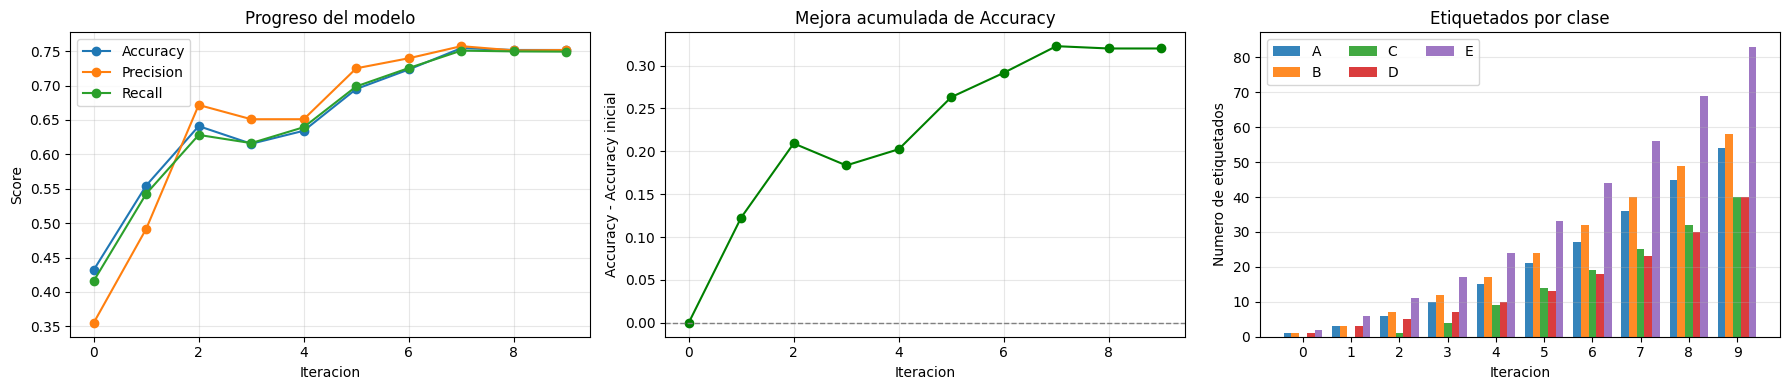

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.431849,0.355051,0.415917,1,1,0,1,2
1,2961,0.554656,0.491704,0.542619,3,3,0,3,6
2,2961,0.641026,0.671761,0.628240,6,7,1,5,11
3,2961,0.615385,0.651036,0.616330,10,12,4,7,17
4,2961,0.634278,0.651062,0.639450,15,17,9,10,24
5,2961,0.695007,0.725054,0.698741,21,24,14,13,33
6,2961,0.723347,0.739663,0.725442,27,32,19,18,44
7,2961,0.754386,0.757220,0.750753,36,40,25,23,56
8,2961,0.751687,0.751021,0.749604,45,49,32,30,69
9,2961,0.751687,0.751642,0.749294,54,58,40,40,83


Iteración 0 registrada. Accuracy: 0.4318


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,1327,B974.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B974.jpg,True,B
registrado,0,1964,E296.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E296.jpg,True,E
registrado,0,436,E442.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E442.jpg,True,E
registrado,0,935,A2291.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2291.jpg,True,A
registrado,0,749,D339.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D339.jpg,True,D
registrado,1,1835,C1339.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1339.jpg,True,C
registrado,1,1527,B866.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B866.jpg,True,B
registrado,1,1155,B271.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B271.jpg,True,B
registrado,1,1518,E1321.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1321.jpg,True,E
registrado,1,2705,A1069.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1069.jpg,True,A



Etiqueta para idx=1327, archivo=B974.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1964, archivo=E296.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=2706, archivo=A2080.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=319, archivo=C1796.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1596, archivo=C547.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1725, archivo=B2192.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=111, archivo=E1101.jpg (opciones: A, B, C, D, E): 


In [39]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `2. Combinación desición tree y query by committee`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4318 | precision=0.3551 | recall=0.4159


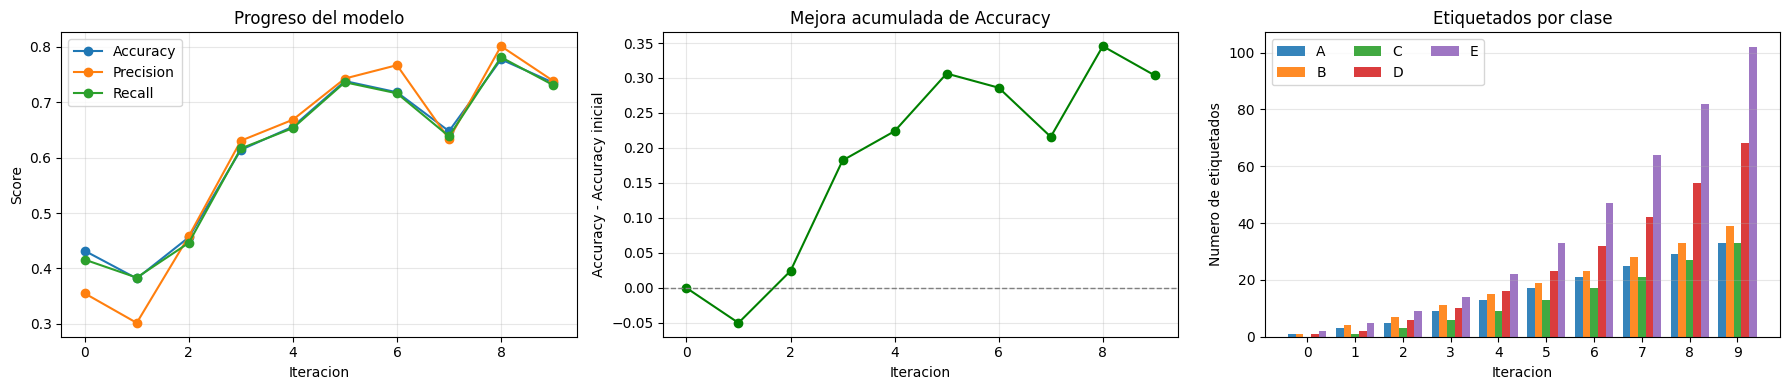

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.431849,0.355051,0.415917,1,1,0,1,2
1,2961,0.381916,0.301764,0.383486,3,4,1,2,5
2,2961,0.456140,0.458172,0.446144,5,7,3,6,9
3,2961,0.614035,0.630511,0.616546,9,11,6,10,14
4,2961,0.655870,0.668427,0.653289,13,15,9,16,22
5,2961,0.738192,0.742774,0.736014,17,19,13,23,33
6,2961,0.717949,0.766872,0.716095,21,23,17,32,47
7,2961,0.647773,0.633482,0.638469,25,28,21,42,64
8,2961,0.777328,0.801169,0.781224,29,33,27,54,82
9,2961,0.735493,0.738585,0.731037,33,39,33,68,102


Iteración 0 registrada. Accuracy: 0.4318


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,186,E1400.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1400.jpg,True,E
registrado,0,135,C273.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C273.jpg,True,C
registrado,0,2600,B1671.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1671.jpg,True,B
registrado,0,2581,B2173.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B2173.jpg,True,B
registrado,0,1874,A1201.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1201.jpg,True,A
registrado,1,2344,C2645.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C2645.jpg,True,C
registrado,1,2861,D2354.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2354.jpg,True,D
registrado,1,2872,D608.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D608.jpg,True,D
registrado,1,1821,E2280.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E2280.jpg,True,E
registrado,1,182,D1626.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1626.jpg,True,D



Etiqueta para idx=186, archivo=E1400.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=135, archivo=C273.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=600, archivo=B1557.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=746, archivo=D1612.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2318, archivo=D2162.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=319, archivo=C1796.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=903, archivo=D396.jpg (opciones: A, B, C, D, E): 


In [45]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `3. Desición tree-Entropia`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4318 | precision=0.3551 | recall=0.4159


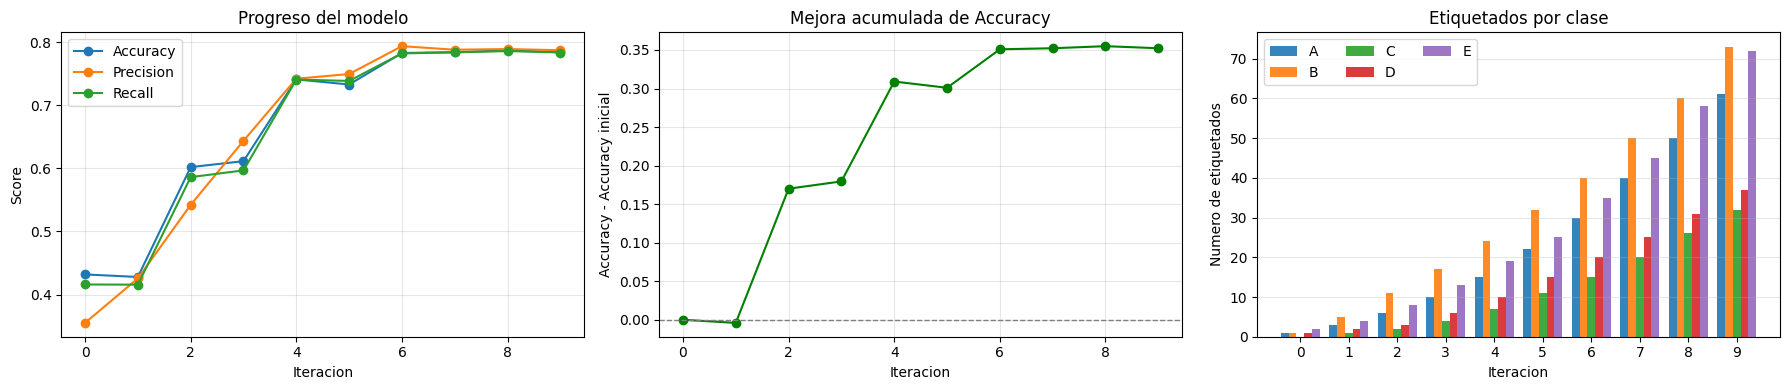

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.431849,0.355051,0.415917,1,1,0,1,2
1,2961,0.427800,0.425605,0.415611,3,5,1,2,4
2,2961,0.601889,0.542033,0.586031,6,11,2,3,8
3,2961,0.611336,0.643604,0.596688,10,17,4,6,13
4,2961,0.740891,0.741970,0.740657,15,24,7,10,19
5,2961,0.732794,0.749381,0.738440,22,32,11,15,25
6,2961,0.782726,0.793545,0.782105,30,40,15,20,35
7,2961,0.784076,0.787906,0.783656,40,50,20,25,45
8,2961,0.786775,0.789005,0.785783,50,60,26,31,58
9,2961,0.784076,0.787113,0.783489,61,73,32,37,72


Iteración 0 registrada. Accuracy: 0.4318


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,2347,C695.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C695.jpg,True,C
registrado,0,871,B1281.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1281.jpg,True,B
registrado,0,2258,B1812.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1812.jpg,True,B
registrado,0,1866,A691.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A691.jpg,True,A
registrado,0,2687,B374.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B374.jpg,True,B
registrado,1,2735,B386.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B386.jpg,True,B
registrado,1,644,B851.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B851.jpg,True,B
registrado,1,2951,E2219.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E2219.jpg,True,E
registrado,1,259,E1975.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1975.jpg,True,E
registrado,1,2919,A659.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A659.jpg,True,A



Etiqueta para idx=2347, archivo=C695.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=871, archivo=B1281.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=352, archivo=D271.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=427, archivo=E758.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2356, archivo=E1444.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2940, archivo=B2291.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1955, archivo=A2645.jpg (opciones: A, B, C, D, E): 


In [53]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `4. Desición tree-margin sampling`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4318 | precision=0.3551 | recall=0.4159


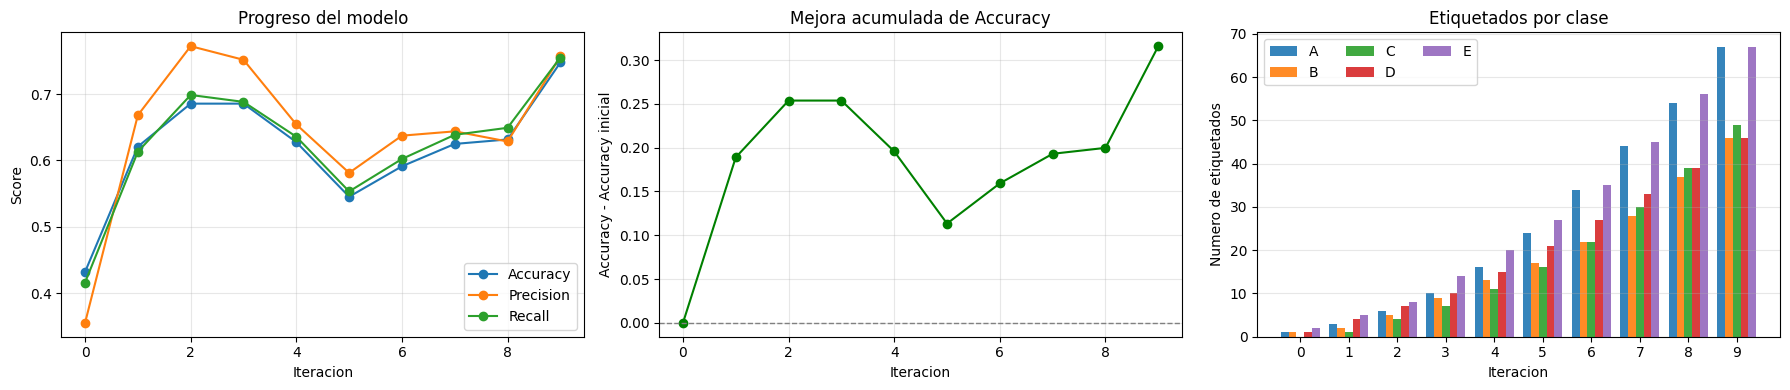

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.431849,0.355051,0.415917,1,1,0,1,2
1,2961,0.620783,0.668150,0.613116,3,2,1,4,5
2,2961,0.685560,0.772193,0.698606,6,5,4,7,8
3,2961,0.685560,0.751640,0.688201,10,9,7,10,14
4,2961,0.627530,0.654204,0.635675,16,13,11,15,20
5,2961,0.545209,0.581235,0.553182,24,17,16,21,27
6,2961,0.591093,0.637287,0.602139,34,22,22,27,35
7,2961,0.624831,0.643795,0.638593,44,28,30,33,45
8,2961,0.631579,0.628503,0.649155,54,37,39,39,56
9,2961,0.747638,0.756634,0.755099,67,46,49,46,67


Iteración 0 registrada. Accuracy: 0.4318


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,1381,A1107.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1107.jpg,True,A
registrado,0,23,C2398.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C2398.jpg,True,C
registrado,0,1234,D1232.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1232.jpg,True,D
registrado,0,2556,D2291.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2291.jpg,True,D
registrado,0,2267,E1972.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1972.jpg,True,E
registrado,1,2104,A1862.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1862.jpg,True,A
registrado,1,2212,C1760.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1760.jpg,True,C
registrado,1,296,B1191.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1191.jpg,True,B
registrado,1,1516,C1587.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1587.jpg,True,C
registrado,1,1486,B2068.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B2068.jpg,True,B



Etiqueta para idx=1381, archivo=A1107.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=23, archivo=C2398.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=1329, archivo=A417.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=517, archivo=C1281.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2922, archivo=B1149.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=596, archivo=E306.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=947, archivo=E1095.jpg (opciones: A, B, C, D, E): 


In [56]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `5. combinación RANDOM FOREST-Random Sampling`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4629 | precision=0.4266 | recall=0.4584


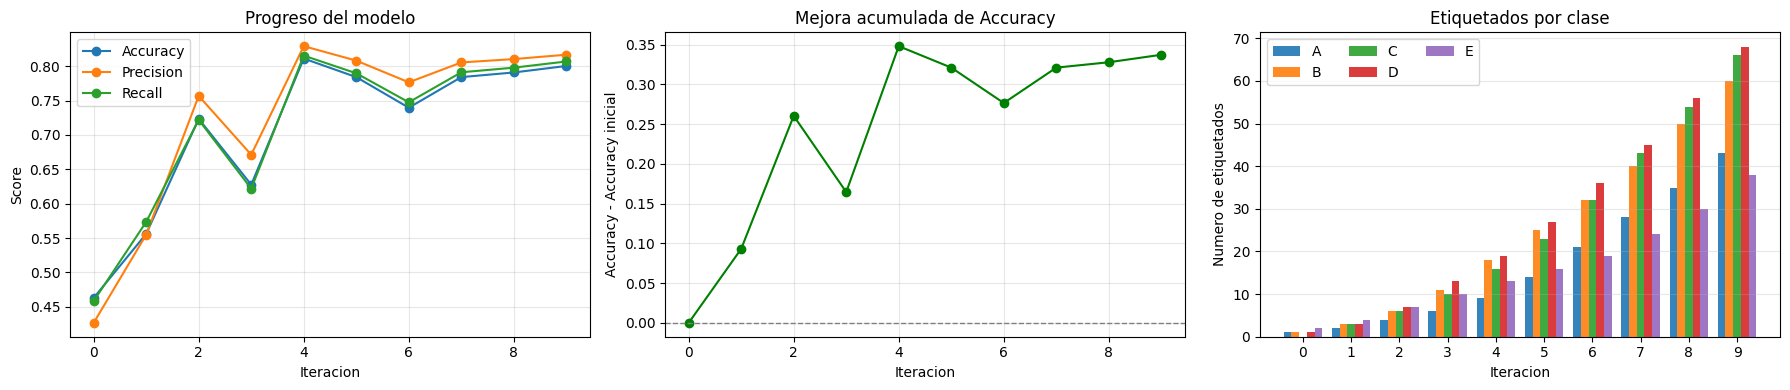

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.462888,0.426570,0.458380,1,1,0,1,2
1,2961,0.556005,0.554897,0.573465,2,3,3,3,4
2,2961,0.723347,0.756759,0.721880,4,6,6,7,7
3,2961,0.627530,0.671136,0.621827,6,11,10,13,10
4,2961,0.811066,0.829064,0.815334,9,18,16,19,13
5,2961,0.784076,0.808047,0.789633,14,25,23,27,16
6,2961,0.739541,0.776492,0.747434,21,32,32,36,19
7,2961,0.784076,0.805392,0.791080,28,40,43,45,24
8,2961,0.790823,0.810295,0.797813,35,50,54,56,30
9,2961,0.800270,0.816644,0.806793,43,60,66,68,38


Iteración 0 registrada. Accuracy: 0.4629


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,2241,C1673.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1673.jpg,True,C
registrado,0,1941,C1548.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1548.jpg,True,C
registrado,0,1426,B1481.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1481.jpg,True,B
registrado,0,182,D1626.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1626.jpg,True,D
registrado,0,2203,C728.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C728.jpg,True,C
registrado,1,1897,B1706.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1706.jpg,True,B
registrado,1,902,D1208.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1208.jpg,True,D
registrado,1,1440,A1241.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1241.jpg,True,A
registrado,1,2741,E831.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E831.jpg,True,E
registrado,1,2820,D468.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D468.jpg,True,D



Etiqueta para idx=2241, archivo=C1673.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1941, archivo=C1548.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=2567, archivo=A2331.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=784, archivo=B1787.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1367, archivo=D1600.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1878, archivo=A1213.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1121, archivo=C1159.jpg (opciones: A, B, C, D, E): 


In [57]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `6. Combinación Random Forest-Entropia` 


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4629 | precision=0.4266 | recall=0.4584


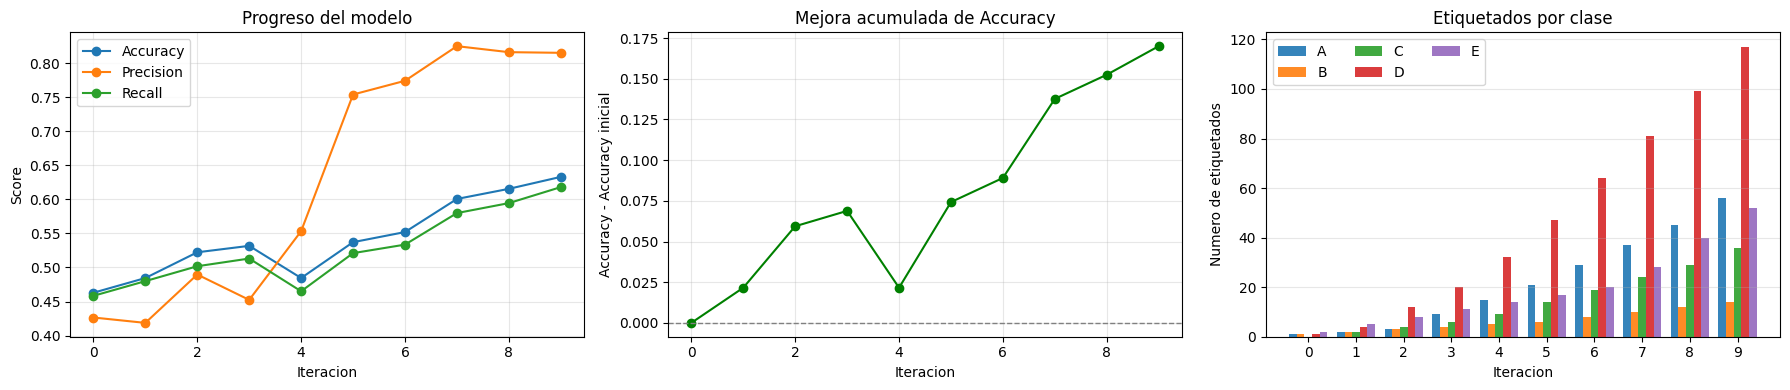

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.462888,0.426570,0.458380,1,1,0,1,2
1,2961,0.484480,0.418672,0.479941,2,2,2,4,5
2,2961,0.522267,0.489640,0.501797,3,3,4,12,8
3,2961,0.531714,0.452423,0.513093,9,4,6,20,11
4,2961,0.484480,0.553261,0.465074,15,5,9,32,14
5,2961,0.537112,0.753785,0.521024,21,6,14,47,17
6,2961,0.551957,0.773918,0.533510,29,8,19,64,20
7,2961,0.600540,0.824732,0.579818,37,10,24,81,28
8,2961,0.615385,0.815940,0.594427,45,12,29,99,40
9,2961,0.632928,0.814971,0.617906,56,14,36,117,52


Iteración 0 registrada. Accuracy: 0.4629


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,2457,C1683.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1683.jpg,True,C
registrado,0,1595,C1131.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C1131.jpg,True,C
registrado,0,653,D2073.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2073.jpg,True,D
registrado,0,2812,D2079.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2079.jpg,True,D
registrado,0,2679,E1367.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1367.jpg,True,E
registrado,1,1953,D2478.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2478.jpg,True,D
registrado,1,2556,D2291.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2291.jpg,True,D
registrado,1,323,D886.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D886.jpg,True,D
registrado,1,2774,D2481.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2481.jpg,True,D
registrado,1,482,D2466.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2466.jpg,True,D



Etiqueta para idx=2457, archivo=C1683.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1595, archivo=C1131.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=1342, archivo=E2112.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=734, archivo=E1588.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1592, archivo=D304.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1369, archivo=D299.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2710, archivo=E1406.jpg (opciones: A, B, C, D, E): 


In [50]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `7. Combinación Random Forest-Query by Committee`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4629 | precision=0.4266 | recall=0.4584


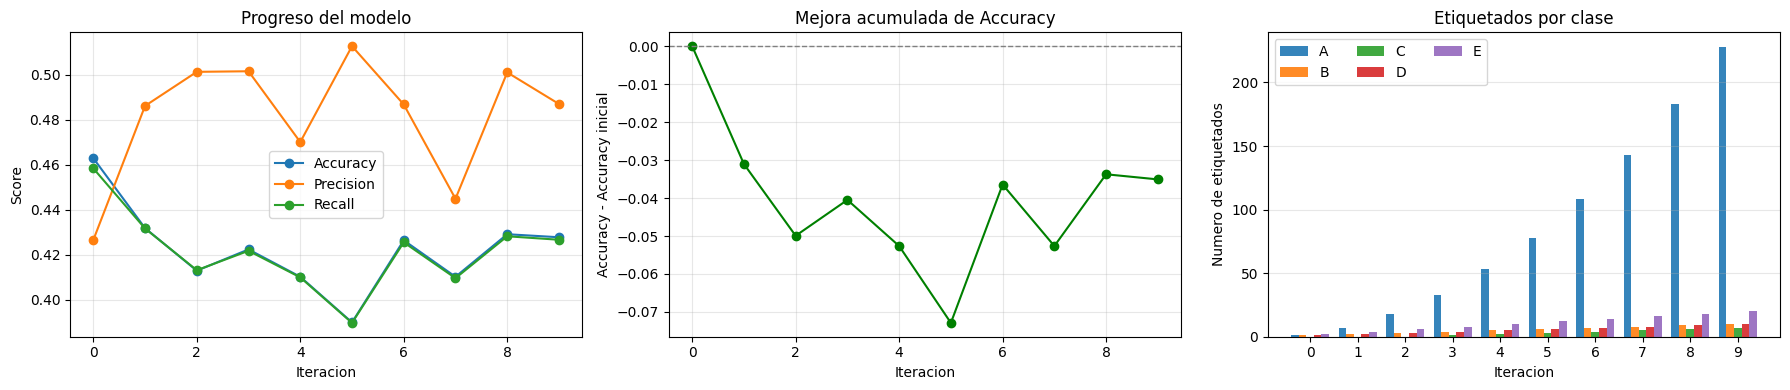

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.462888,0.426570,0.458380,1,1,0,1,2
1,2961,0.431849,0.486099,0.431691,7,2,0,2,4
2,2961,0.412955,0.501218,0.413170,18,3,0,3,6
3,2961,0.422402,0.501477,0.421783,33,4,1,4,8
4,2961,0.410256,0.470048,0.409998,53,5,2,5,10
5,2961,0.390013,0.512612,0.389793,78,6,3,6,12
6,2961,0.426451,0.486733,0.425549,108,7,4,7,14
7,2961,0.410256,0.444891,0.409642,143,8,5,8,16
8,2961,0.429150,0.500963,0.428234,183,9,6,9,18
9,2961,0.427800,0.486954,0.426691,228,10,7,10,20


Iteración 0 registrada. Accuracy: 0.4629


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,364,A1052.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1052.jpg,True,A
registrado,0,1731,A1131.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1131.jpg,True,A
registrado,0,2549,A1067.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1067.jpg,True,A
registrado,0,568,A1028.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1028.jpg,True,A
registrado,0,2144,A1053.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1053.jpg,True,A
registrado,1,1166,A954.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A954.jpg,True,A
registrado,1,84,A2084.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2084.jpg,True,A
registrado,1,1162,A1559.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1559.jpg,True,A
registrado,1,1009,A1560.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1560.jpg,True,A
registrado,1,2793,A450.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A450.jpg,True,A



Etiqueta para idx=364, archivo=A1052.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1731, archivo=A1131.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=155, archivo=A1111.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=222, archivo=A2.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1237, archivo=A689.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2027, archivo=A679.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1702, archivo=A28.jpg (opciones: A, B, C, D, E): 


In [51]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `8. Combinación random forest-margin sampling`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.4629 | precision=0.4266 | recall=0.4584


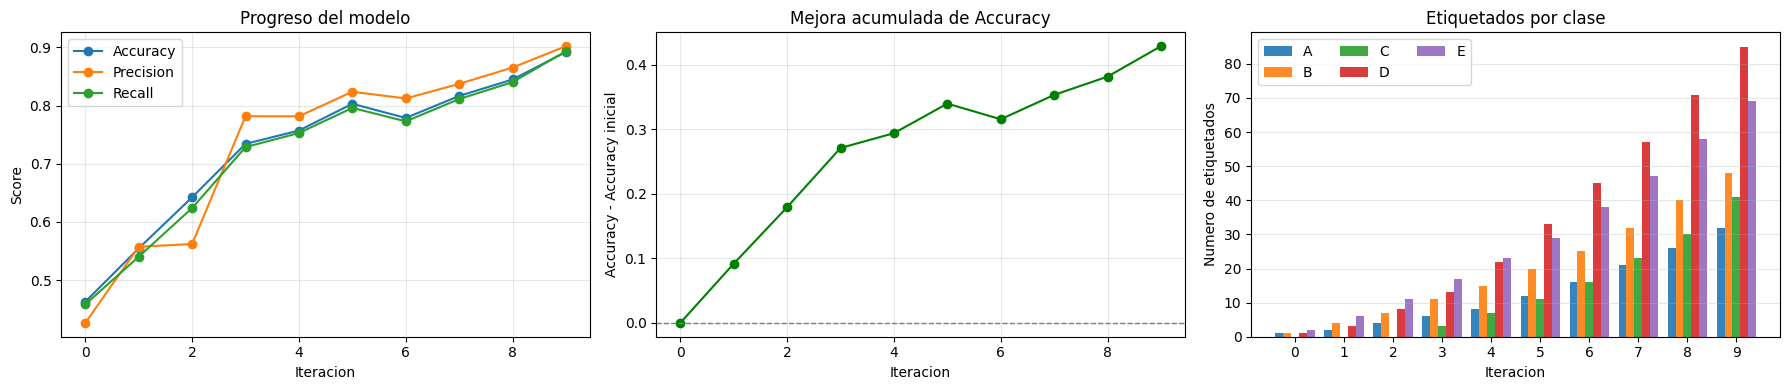

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.462888,0.426570,0.458380,1,1,0,1,2
1,2961,0.554656,0.557397,0.540313,2,4,0,3,6
2,2961,0.642375,0.562084,0.623927,4,7,0,8,11
3,2961,0.734143,0.781621,0.728554,6,11,3,13,17
4,2961,0.757085,0.781516,0.752816,8,15,7,22,23
5,2961,0.802969,0.823750,0.795929,12,20,11,33,29
6,2961,0.778677,0.812111,0.772824,16,25,16,45,38
7,2961,0.816464,0.837284,0.811160,21,32,23,57,47
8,2961,0.844804,0.865278,0.840226,26,40,30,71,58
9,2961,0.892038,0.902005,0.893317,32,48,41,85,69


Iteración 0 registrada. Accuracy: 0.4629


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,2683,E2241.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E2241.jpg,True,E
registrado,0,2091,D1897.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1897.jpg,True,D
registrado,0,1570,B959.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B959.jpg,True,B
registrado,0,2635,E554.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E554.jpg,True,E
registrado,0,1296,B2572.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B2572.jpg,True,B
registrado,1,1042,A2632.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2632.jpg,True,A
registrado,1,919,E1866.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1866.jpg,True,E
registrado,1,209,D1353.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1353.jpg,True,D
registrado,1,2432,D392.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D392.jpg,True,D
registrado,1,808,D321.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D321.jpg,True,D



Etiqueta para idx=2683, archivo=E2241.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2091, archivo=D1897.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=2610, archivo=D208.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=777, archivo=D2102.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=336, archivo=C383.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1823, archivo=A2651.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1066, archivo=C1938.jpg (opciones: A, B, C, D, E): 


In [58]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `9. Combinación SVM-Random Sampling`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.3792 | precision=0.4499 | recall=0.3753


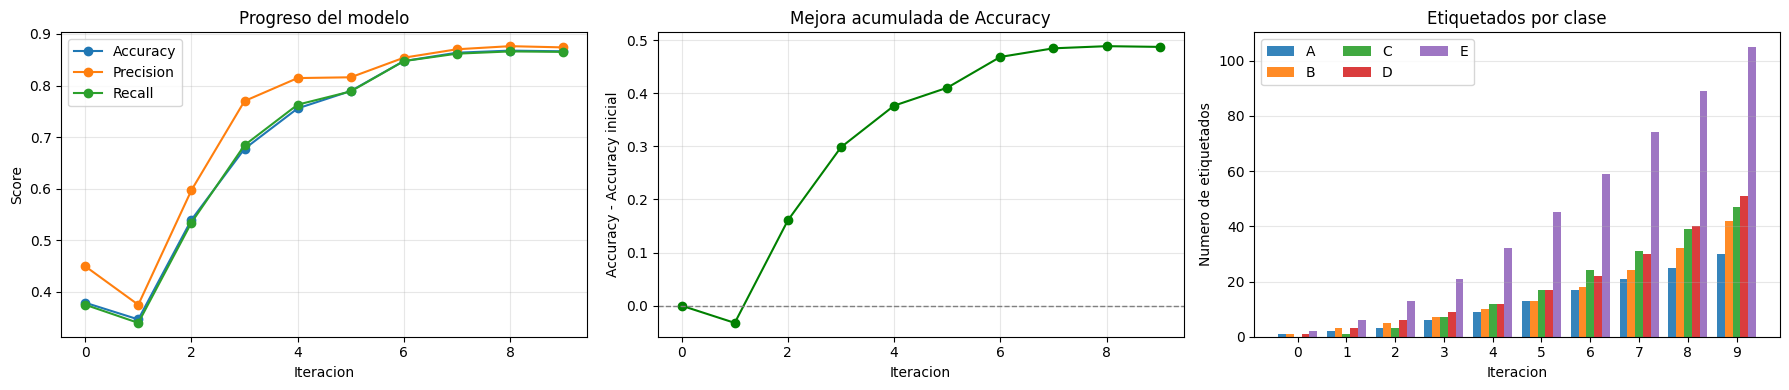

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.379217,0.449918,0.375330,1,1,0,1,2
1,2961,0.346829,0.375208,0.340116,2,3,1,3,6
2,2961,0.539811,0.597102,0.534301,3,5,3,6,13
3,2961,0.677463,0.769978,0.684463,6,7,7,9,21
4,2961,0.755735,0.814526,0.762966,9,10,12,12,32
5,2961,0.789474,0.816041,0.788670,13,13,17,17,45
6,2961,0.847503,0.854006,0.847420,17,18,24,22,59
7,2961,0.863698,0.870335,0.861812,21,24,31,30,74
8,2961,0.867746,0.876348,0.866173,25,32,39,40,89
9,2961,0.866397,0.873974,0.865299,30,42,47,51,105


Iteración 0 registrada. Accuracy: 0.3792


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,892,B1301.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1301.jpg,True,B
registrado,0,2829,D1651.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1651.jpg,True,D
registrado,0,897,E1937.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1937.jpg,True,E
registrado,0,449,C166.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C166.jpg,True,C
registrado,0,1271,E2201.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E2201.jpg,True,E
registrado,1,1051,C271.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C271.jpg,True,C
registrado,1,273,E2072.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E2072.jpg,True,E
registrado,1,283,E1983.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1983.jpg,True,E
registrado,1,489,E392.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E392.jpg,True,E
registrado,1,1768,D2589.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2589.jpg,True,D



Etiqueta para idx=892, archivo=B1301.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2829, archivo=D1651.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=116, archivo=C1956.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=15, archivo=A1181.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2301, archivo=E1980.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=502, archivo=D1077.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2087, archivo=C1211.jpg (opciones: A, B, C, D, E): 


In [52]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `10. Combinación SVM-Query by Committee`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.3792 | precision=0.4499 | recall=0.3753


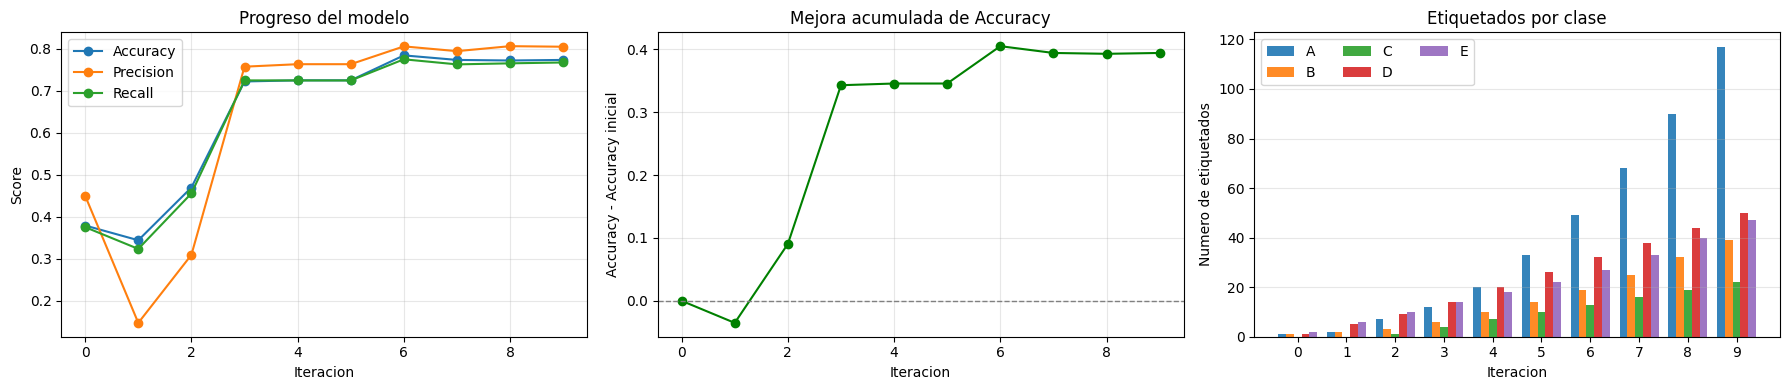

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.379217,0.449918,0.375330,1,1,0,1,2
1,2961,0.344130,0.147486,0.323541,2,2,0,5,6
2,2961,0.469636,0.309357,0.455584,7,3,1,9,10
3,2961,0.721997,0.757206,0.724547,12,6,4,14,14
4,2961,0.724696,0.763107,0.724440,20,10,7,20,18
5,2961,0.724696,0.763107,0.724440,33,14,10,26,22
6,2961,0.784076,0.805490,0.774756,49,19,13,32,27
7,2961,0.773279,0.794155,0.762692,68,25,16,38,33
8,2961,0.771930,0.806010,0.765150,90,32,19,44,40
9,2961,0.773279,0.804683,0.767209,117,39,22,50,47


Iteración 0 registrada. Accuracy: 0.3792


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,144,E1817.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1817.jpg,True,E
registrado,0,2068,E1677.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E1677.jpg,True,E
registrado,0,2261,D2929.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D2929.jpg,True,D
registrado,0,112,D611.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D611.jpg,True,D
registrado,0,2227,D1904.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1904.jpg,True,D
registrado,1,10,C589.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\C\C589.jpg,True,C
registrado,1,2622,A1757.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1757.jpg,True,A
registrado,1,1806,A2365.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2365.jpg,True,A
registrado,1,1400,A1469.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A1469.jpg,True,A
registrado,1,2561,A701.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A701.jpg,True,A



Etiqueta para idx=144, archivo=E1817.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2068, archivo=E1677.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=1184, archivo=A1641.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2477, archivo=A627.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=780, archivo=A1722.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=537, archivo=A695.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=735, archivo=A1400.jpg (opciones: A, B, C, D, E): 


In [59]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `11. Combinación SVM-Entropia`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.3792 | precision=0.4499 | recall=0.3753


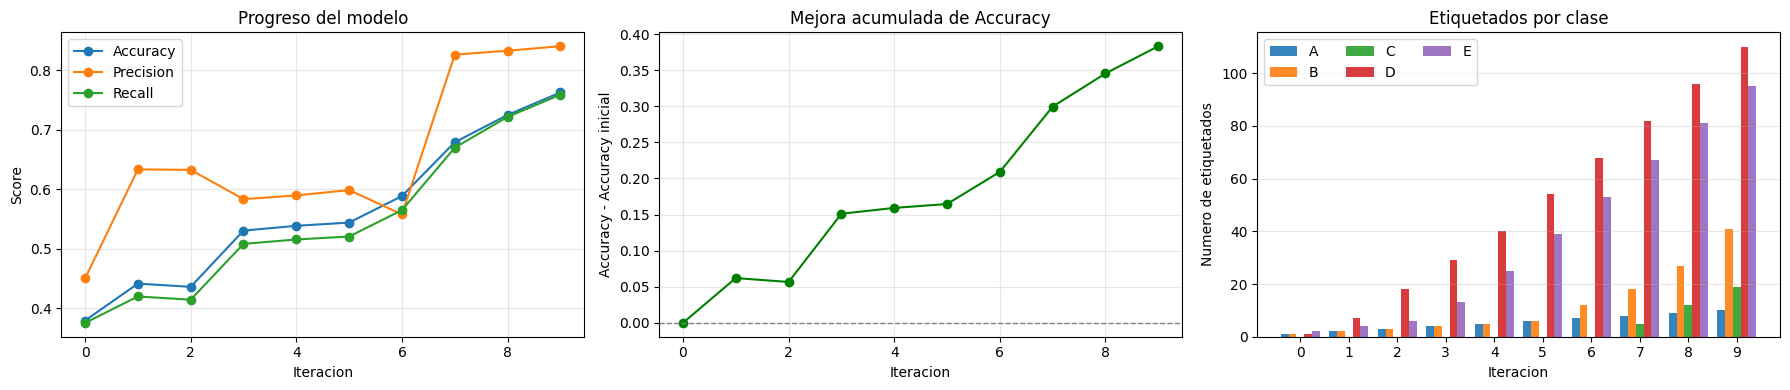

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.379217,0.449918,0.375330,1,1,0,1,2
1,2961,0.441296,0.633273,0.419705,2,2,0,7,4
2,2961,0.435897,0.632430,0.414295,3,3,0,18,6
3,2961,0.530364,0.583274,0.508102,4,4,0,29,13
4,2961,0.538462,0.589491,0.515433,5,5,0,40,25
5,2961,0.543860,0.598462,0.520456,6,6,0,54,39
6,2961,0.588394,0.557631,0.564752,7,12,0,68,53
7,2961,0.678812,0.826055,0.669720,8,18,5,82,67
8,2961,0.724696,0.832593,0.721420,9,27,12,96,81
9,2961,0.762483,0.840252,0.758795,10,41,19,110,95


Iteración 0 registrada. Accuracy: 0.3792


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,33,D1362.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1362.jpg,True,D
registrado,0,749,D339.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D339.jpg,True,D
registrado,0,778,D382.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D382.jpg,True,D
registrado,0,1658,D365.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D365.jpg,True,D
registrado,0,1419,D386.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D386.jpg,True,D
registrado,1,176,D1241.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1241.jpg,True,D
registrado,1,2883,D330.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D330.jpg,True,D
registrado,1,2444,D1238.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1238.jpg,True,D
registrado,1,209,D1353.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1353.jpg,True,D
registrado,1,1494,D869.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D869.jpg,True,D



Etiqueta para idx=33, archivo=D1362.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=749, archivo=D339.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=2473, archivo=B1261.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1579, archivo=B1262.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2786, archivo=B739.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1368, archivo=B1294.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2369, archivo=B1067.jpg (opciones: A, B, C, D, E): 


In [60]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

### `12. Combinación SVM-margin sampling`


Selecciona el modelo para Active Learning manual:
  1. Decision Tree
  2. Random Forest
  3. SVM

Selecciona la estrategia de muestreo:
  1. Random Sampling
  2. Query by Committee
  3. Uncertainty Sampling - Entropy
  4. Uncertainty Sampling - Margin
Iteracion 0 | etiquetadas=2961 | acc=0.3792 | precision=0.4499 | recall=0.3753


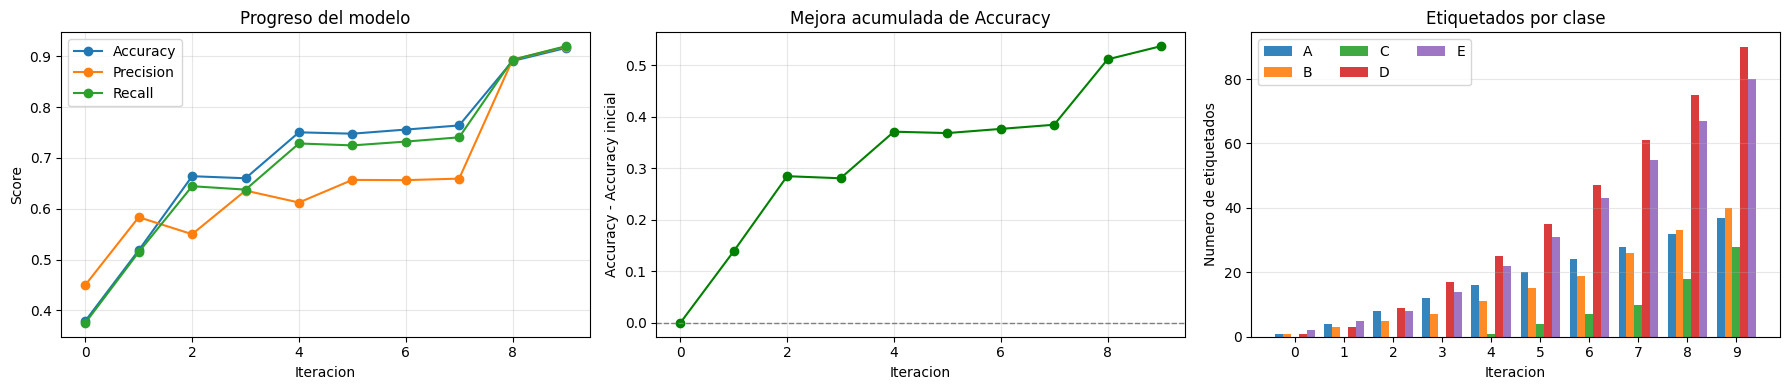

iteracion,etiquetadas,accuracy,precision_macro,recall_macro,label_count_A,label_count_B,label_count_C,label_count_D,label_count_E
0,2961,0.379217,0.449918,0.375330,1,1,0,1,2
1,2961,0.518219,0.583333,0.514637,4,3,0,3,5
2,2961,0.663968,0.549857,0.644279,8,5,0,9,8
3,2961,0.659919,0.635693,0.637574,12,7,0,17,14
4,2961,0.750337,0.612177,0.728363,16,11,1,25,22
5,2961,0.747638,0.656682,0.724612,20,15,4,35,31
6,2961,0.755735,0.656223,0.732072,24,19,7,47,43
7,2961,0.763833,0.659216,0.740472,28,26,10,61,55
8,2961,0.890688,0.893133,0.893182,32,33,18,75,67
9,2961,0.916329,0.918935,0.919858,37,40,28,90,80


Iteración 0 registrada. Accuracy: 0.3792


evento,iteracion,idx_pool,filename,image_path,imagen_mostrada,label_elegida
registrado,0,2817,B1676.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\B\B1676.jpg,True,B
registrado,0,1323,D1281.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1281.jpg,True,D
registrado,0,1244,E578.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\E\E578.jpg,True,E
registrado,0,865,A712.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A712.jpg,True,A
registrado,0,1932,A2392.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2392.jpg,True,A
registrado,1,2297,D1928.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1928.jpg,True,D
registrado,1,215,D1919.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1919.jpg,True,D
registrado,1,63,D1939.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1939.jpg,True,D
registrado,1,2595,D1937.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\D\D1937.jpg,True,D
registrado,1,2396,A2574.jpg,C:\Users\makia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train/asl_alphabet_train\A\A2574.jpg,True,A



Etiqueta para idx=2817, archivo=B1676.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1323, archivo=D1281.jpg (opciones: A, B, C, D, E): 


...


Etiqueta para idx=746, archivo=D1612.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=883, archivo=D726.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2319, archivo=E2887.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=2093, archivo=D482.jpg (opciones: A, B, C, D, E): 



Etiqueta para idx=1105, archivo=E2972.jpg (opciones: A, B, C, D, E): 


In [61]:
filenames_series = df_train["filename"].values
image_base_dir = train_dir
image_index = Viewer._build_image_index(image_base_dir)

viewer = Viewer(
    image_base_dir=image_base_dir,
    image_index=image_index,
)

model_names = [cfg["modelo"] for cfg in modelos]
selected_model_name = Viewer._ask_choice("Selecciona el modelo para Active Learning manual:", model_names)
selected_model_cfg = next(cfg for cfg in modelos if cfg["modelo"] == selected_model_name)

strategy_names = list(estrategias.keys())
selected_strategy_name = Viewer._ask_choice("Selecciona la estrategia de muestreo:", strategy_names)
query_selector_to_use = estrategias[selected_strategy_name]


run_manual_active_learning(
    estimator=selected_model_cfg["instance"], 
    X= df_train[features].values, # Ajustar según su definición
    y_true=  df_train["label"].values,# Ajustar según su definición
    filenames =np.asarray(filenames_series),
    viewer=viewer,                            
    query_selector=query_selector_to_use,   
    initial_size=5,                         
    query_size=5,      
    test_size=0.2,         
    random_state=42,      
    max_iterations=10,                    
)

## Analisis de Resultados

| # | Combinación | Accuracy | Precision | Recall |
|---|---|---|---|---|
| 1 | Decision Tree + Random Sampling | 0.7517 | 0.7516 | 0.7493 |
| 2 | Decision Tree + QBC | 0.7355 | 0.7386 | 0.7310 |
| 3 | Decision Tree + Entropy | 0.7841 | 0.7871 | 0.7835 |
| 4 | Decision Tree + Margin Sampling | 0.7476 | 0.7566 | 0.7551 |
| 5 | Random Forest + Random Sampling | 0.8003 | 0.8166 | 0.8068 |
| 6 | Random Forest + Entropy | 0.6329 | 0.8150 | 0.6179 |
| 7 | Random Forest + QBC | 0.4278 | 0.4870 | 0.4267 |
| 8 | Random Forest + Margin Sampling | 0.8920 | 0.9020 | 0.8933 |
| 9 | SVM + Random Sampling | 0.8664 | 0.8740 | 0.8653 |
| 10 | SVM + QBC | 0.7733 | 0.8047 | 0.7672 |
| 11 | SVM + Entropy | 0.7625 | 0.8403 | 0.7588 |
| 12 | SVM + Margin Sampling | **0.9163** | **0.9189** | **0.9199** |


-`¿Qué diferencias observas en
la velocidad de aprendizaje al utilizar una selección aleatoria versus una basada en incertidumbre o
en el desacuerdo del comité? ¿Hubo algún modelo (DT, RF, SVM) que se beneficiara más del Active
Learning que los otros?`

Las estrategias badas en incertidumbre o en el desacuerdo del comité generalmente muestran una velocidad de aprendizaje más rápida en comparación con la selección aleatoria. Esto se debe a que estas estrategias seleccionan instancias que son más informativas para el modelo, a comparación con la selección aleatoria que puede seleccionar instancias que el modelo ya conoce o son pocas informativas. En la tabla se puede observar que las estrategias basadas en incertidumbre y desacuerdo del comité generalmente tienen un mejor rendimiento en términos de accuracy, precision y recall en comparación con la selección aleatoria en pocas iteraciones.

SVM fue el modelo que más se beneficio del Active Learning, esto de puse observar en la tabla, donde SVM presenta el mayor accuracy, precision y recall en comparación con los otros modelos. Esto se debe a que SVM es un modelo que se beneficia mucho de tener datos etiquetados de alta calidad, y estrategias como Margin Sampling permiten elegir imagenes que se encuentran en el margen de desicion, es decir, donde el modelo duda entre dos clases. Esto hace que el modelo aprenda de manera más eficiente, ya que se enfoca en las instancias más informativas Y permita encontrar el hiperplano de separación de manera más rápida. 

-`Basándote en tu interacción directa con la interfaz, ¿notaste visual
mente algún patrón en las imágenes de las manos que el modelo te pedía etiquetar cuando usabas
Uncertainty Sampling o QBC? ¿Te parecieron casos genuinamente más difíciles, ambiguos o inusua
les en comparación con el muestreo aleatorio?`

Si, existe un patron claro en las imagenes que el modelo selecciona para etiquetar cuando se utiliza Uncertainty Sampling o QBC, donde son más complejas de seleccionar. Estas estrategias tienden  a seleccionar imágenes más complejas o donde tengan dudas. Por ejemplo, en Uncertainty Sampling, cuando es entropia, se busca las imagenes donde el modelo esta más confundio es decir que la distribución de probabilidad entre las clases sean más parecidas. Cuando es margin sampling, se buscan imagenes que esten en un margen, es decir, donde el modelo no sepa decidir si le pertenece a una clase A o a una clase B. Y en QBC, se buscan imagenes donde el comite de los modelos (en este caso, conformado por tres clones del modelo base) tengan mayor desacuerdo, es decir, que cada modelo prediga diferente. (Parra, D., 2026) Esto hace que las imagenes seleccionadas por estas estrategias sean más difíciles, ambiguas o inusuales en comparación con el muestreo aleatorio, que puede seleccionar cualquier imagen sin importar su nivel de dificultad o incertidumbre para el modelo.

## Tercera Parte: Simulación Automatizada de Active Learning

En esta etapa se espera que automaticen el rol del "Oráculo" usando las etiquetas reales del dataset. Esto nos permitirá simular y evaluar cómo se comportan nuestros 3 modelos combinados con diferentes estrategias de muestreo a mayor escala pero con un presupuesto máximo de 150 Tokens (1 token = 1 nueva imagen etiquetada por el oráculo).

# Referencias

- Shin, J., Matsuoka, A., Hasan, M. A. M., & Srizon, A. Y. (2021). American Sign Language Alphabet Recognition by Extracting Feature from Hand Pose Estimation. Sensors (Basel, Switzerland), 21(17), 5856. https://doi.org/10.3390/s21175856

- Christof. (2023, November 15). The Alphabet in ASL Sign Language | Learn American Sign Language. Lingvano ASL. https://www-lingvano-com.translate.goog/asl/blog/sign-language-alphabet/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

- Herde, M., Pham, M. T., Tharwat, A., & Sick, B. (2024). Tutorial: Interactive Adaptive Learning. En Proceedings of the 8th Interactive Adaptive Learning Workshop. Vilnius, Lithuania. Recuperado de https://www.activeml.net/ial2024/pdf/paper1.pdf
- Parra, D. (2026). *Active Learning: Aprendizaje activo con datos escasos* [Presentación de PDF]. IIC2613 Inteligencia Artificial, Pontificia Universidad Católica de Chile.
- scikit-learn developers. (s.f.). train_test_split — scikit-learn documentation. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Mukherjee, A. (2024). Why do we use stratify in train_test_split? Medium. https://medium.com/@aymuosmukherjee/why-do-we-use-stratify-in-train-test-split-e3eb296a5494